# Gene Expression Analysis using PCA

## Objective
Perform gene expression analysis using Principal Component Analysis (PCA) to identify patterns and clustering among different cell types.

---

## Dataset

The dataset contains gene expression values for five genes across five cells.

| Cell_ID | Gene1 | Gene2 | Gene3 | Gene4 | Gene5 | Cell_Type |
|----------|-------|-------|-------|-------|-------|------------|
| Cell_1   | 5.2   | 3.1   | 7.8   | 2.4   | 6.5   | Type_A     |
| Cell_2   | 4.8   | 2.9   | 7.2   | 2.1   | 6.1   | Type_A     |
| Cell_3   | 1.2   | 8.5   | 2.3   | 9.1   | 3.4   | Type_B     |
| Cell_4   | 1.5   | 8.9   | 2.7   | 9.5   | 3.8   | Type_B     |
| Cell_5   | 6.1   | 3.5   | 8.2   | 2.6   | 6.9   | Type_A     |

---

## Tasks

1. Load the dataset into Python.
2. Standardize the gene expression values.
3. Perform Principal Component Analysis (PCA).
4. Plot PCA results (PC1 vs PC2).
5. Generate a Scree Plot.
6. Generate a Heatmap to visualize gene expression clustering.
7. Interpret the clustering results.

---

## Expected Outcome

- Identify whether Type_A and Type_B cells form separate clusters.
- Determine how much variance is explained by principal components.
- Visualize gene expression patterns using heatmap.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
# Create Dataset
data = {
    "Cell_ID": ["Cell_1", "Cell_2", "Cell_3", "Cell_4", "Cell_5"],
    "Gene1": [5.2, 4.8, 1.2, 1.5, 6.1],
    "Gene2": [3.1, 2.9, 8.5, 8.9, 3.5],
    "Gene3": [7.8, 7.2, 2.3, 2.7, 8.2],
    "Gene4": [2.4, 2.1, 9.1, 9.5, 2.6],
    "Gene5": [6.5, 6.1, 3.4, 3.8, 6.9],
    "Cell_Type": ["Type_A", "Type_A", "Type_B", "Type_B", "Type_A"]
}

In [3]:
df = pd.DataFrame(data)
df.set_index("Cell_ID", inplace=True)

print("Original Dataset")
print(df)

Original Dataset
         Gene1  Gene2  Gene3  Gene4  Gene5 Cell_Type
Cell_ID                                             
Cell_1     5.2    3.1    7.8    2.4    6.5    Type_A
Cell_2     4.8    2.9    7.2    2.1    6.1    Type_A
Cell_3     1.2    8.5    2.3    9.1    3.4    Type_B
Cell_4     1.5    8.9    2.7    9.5    3.8    Type_B
Cell_5     6.1    3.5    8.2    2.6    6.9    Type_A


In [4]:
# Standardize Gene Expression
features = ["Gene1","Gene2","Gene3","Gene4","Gene5"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features, index=df.index)

print("\nStandardized Data")
print(scaled_df)


Standardized Data
            Gene1     Gene2     Gene3     Gene4     Gene5
Cell_ID                                                  
Cell_1   0.714801 -0.838054  0.835079 -0.805242  0.800781
Cell_2   0.516245 -0.911568  0.603113 -0.893407  0.524650
Cell_3  -1.270757  1.146811 -1.291280  1.163780 -1.339237
Cell_4  -1.121840  1.293838 -1.136636  1.281334 -1.063106
Cell_5   1.161551 -0.691027  0.989724 -0.746465  1.076913


In [5]:
# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result,
                      columns=[f"PC{i+1}" for i in range(len(features))],
                      index=df.index)

pca_df["Cell_Type"] = df["Cell_Type"]

print("\nPCA Result")
print(pca_df)


PCA Result
              PC1       PC2       PC3       PC4           PC5 Cell_Type
Cell_ID                                                                
Cell_1   1.786198 -0.061588 -0.075872  0.015588 -1.514327e-17    Type_A
Cell_2   1.541554 -0.396952  0.020848 -0.015784 -1.514327e-17    Type_A
Cell_3  -2.778450 -0.150440  0.051993  0.014946 -1.514327e-17    Type_B
Cell_4  -2.636617  0.204743 -0.051126 -0.014565 -1.514327e-17    Type_B
Cell_5   2.087315  0.404237  0.054157 -0.000185 -1.514327e-17    Type_A


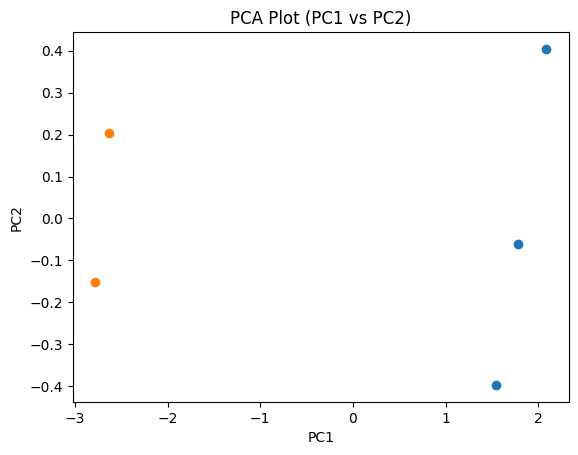

In [6]:
# PCA Scatter Plot (PC1 vs PC2)
plt.figure()

for cell_type in pca_df["Cell_Type"].unique():
    subset = pca_df[pca_df["Cell_Type"] == cell_type]
    plt.scatter(subset["PC1"], subset["PC2"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Plot (PC1 vs PC2)")
plt.show()

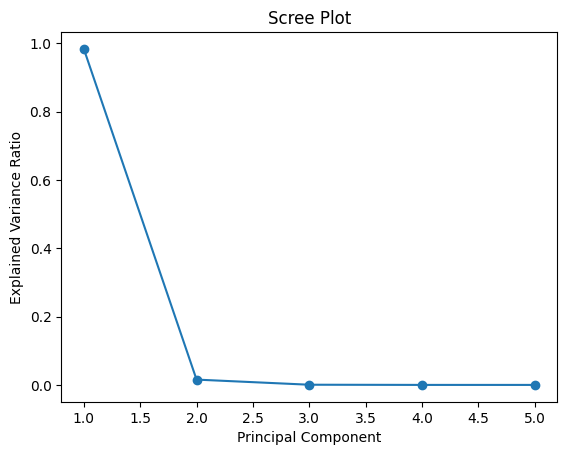


Explained Variance Ratio:
[9.83812297e-01 1.55729439e-02 5.77651145e-04 3.71079295e-05
 4.58637296e-35]


In [7]:
# Scree Plot
explained_variance = pca.explained_variance_ratio_

plt.figure()
plt.plot(range(1, len(features)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

print("\nExplained Variance Ratio:")
print(explained_variance)

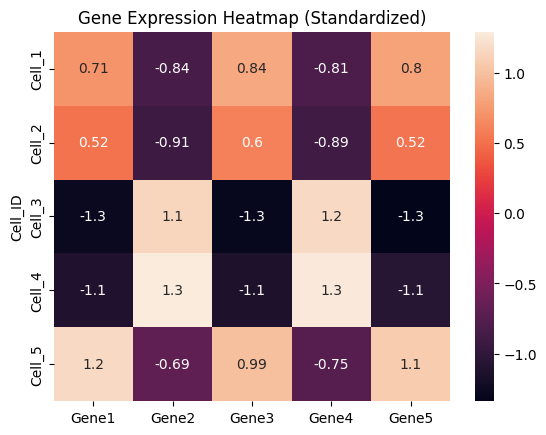

In [8]:
# Heatmap (Gene Expression Clustering)
plt.figure()
sns.heatmap(scaled_df, annot=True)
plt.title("Gene Expression Heatmap (Standardized)")
plt.show()

## Interpretation of Clustering Results

After performing PCA and visualizing the data using the PC1 vs PC2 scatter plot, we observe a clear separation between the two cell types.

- Cells labeled **Type_A (Cell_1, Cell_2, Cell_5)** tend to cluster together.
- Cells labeled **Type_B (Cell_3, Cell_4)** form a separate cluster.
- This indicates that the gene expression patterns of Type_A and Type_B cells are significantly different.

From the Scree Plot:
- The first principal component (PC1) explains the majority of the variance in the dataset.
- PC2 explains additional but smaller variance.
- Since most variance is captured by PC1 and PC2, the 2D PCA plot effectively represents the structure of the data.

From the Heatmap:
- Type_A cells show higher expression in Gene1, Gene3, and Gene5.
- Type_B cells show higher expression in Gene2 and Gene4.
- This confirms distinct gene expression signatures between the two cell types.

### Conclusion
The clustering results indicate strong separation between Type_A and Type_B cells based on gene expression patterns. PCA successfully reduced dimensionality while preserving meaningful biological differences between the cell types.